Dataset created successfully!
Total images: 1500
Pixels per image: 784
Number of classes: 10

Training images: 1200
Testing images: 300


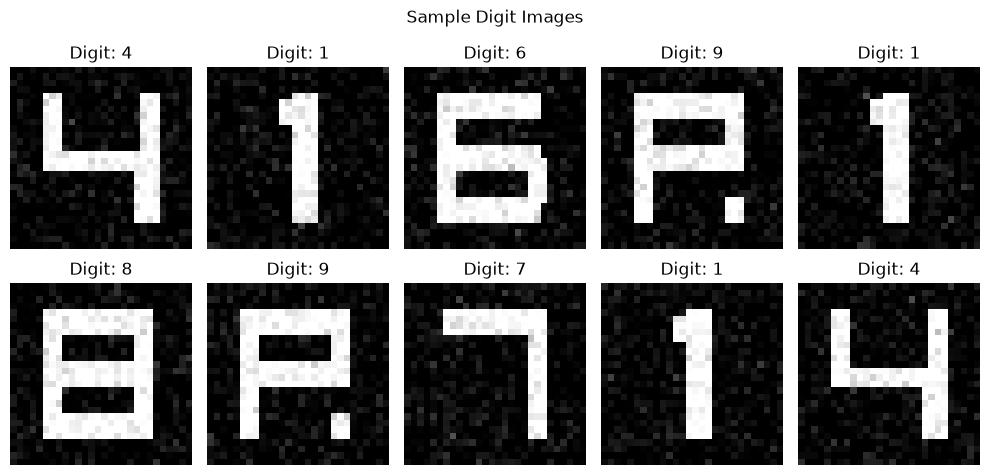


First image numerical representation:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 5.76563552e-02
 0.00000000e+00 7.03194831e-03 2.74021942e-02 0.00000000e+00
 2.88280398e-02 0.00000000e+00 9.86152440e-02 5.04591875e-03
 9.00156200e-02 0.00000000e+00 4.78447191e-02 0.00000000e+00
 7.47717032e-03 1.42355906e-02 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.29914638e-02 0.00000000e+00 6.58686906e-02
 6.42693490e-02 0.00000000e+00 0.00000000e+00 5.02297729e-02
 0.00000000e+00 8.94752294e-02 0.00000000e+00 1.28607620e-02
 0.00000000e+00 9.27333981e-02 0.00000000e+00 6.78695887e-02
 7.53544718e-02 4.33936901e-02 0.00000000e+00 0.00000000e+00
 2.74524037e-02 3.07094660e-02 0.00000000e+00 0.00000000e+00
 5.96393198e-02 1.01991072e-01 6.85024187e-02 2.20014490e-02
 0.00000000e+00 0.00000000e+00 3.77498679e-02 1.16139781e-02
 7.92974234e-02 0.00000000e+00 6.42985478e-02 3.11486963e-02
 1.14736609e-01 1.70015283e-02 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.58031979e-02 8.96551907e-02 

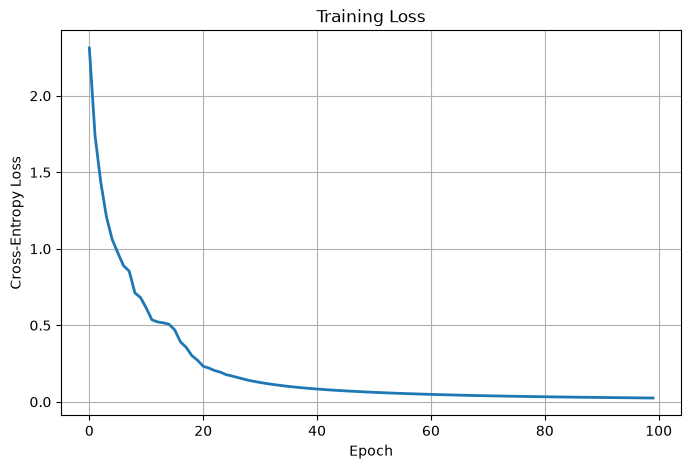

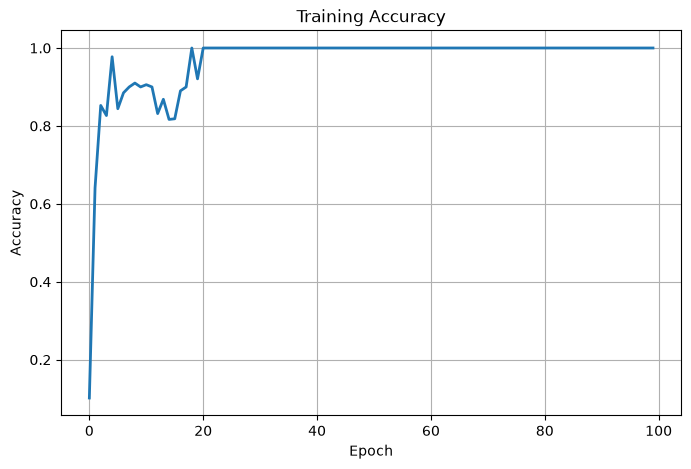

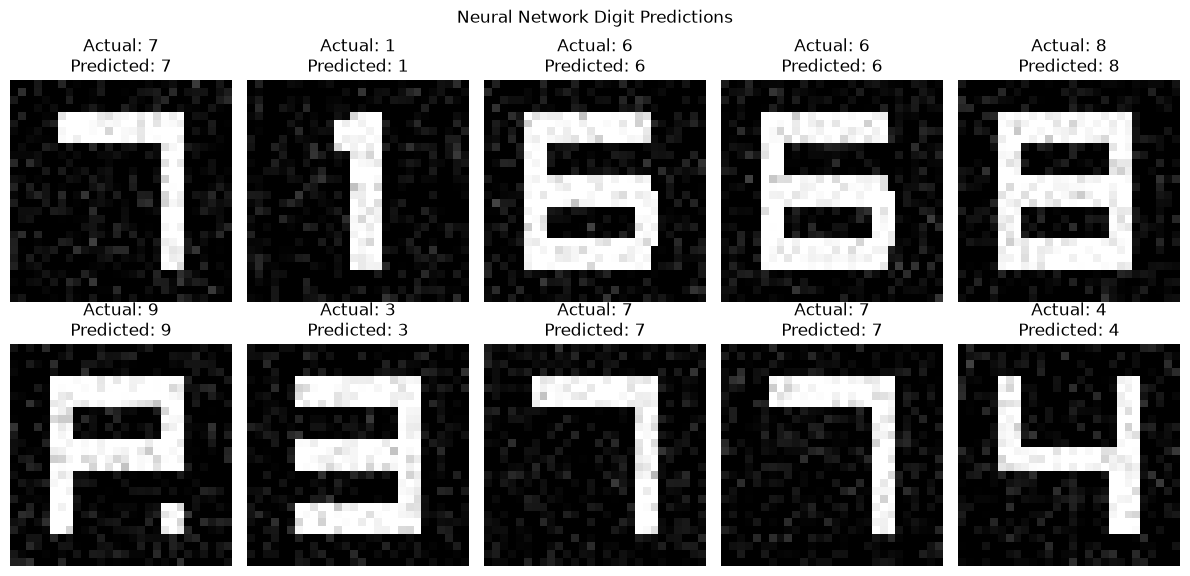

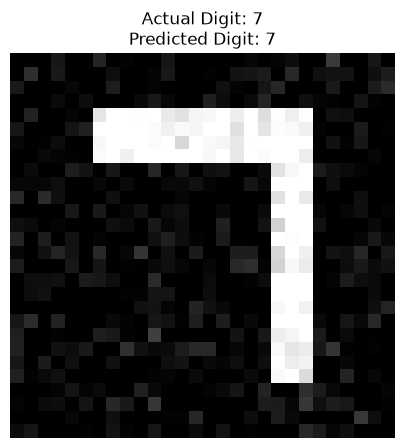


Class probabilities:
Digit 0 : 0.08 %
Digit 1 : 0.04 %
Digit 2 : 0.06 %
Digit 3 : 0.54 %
Digit 4 : 0.13 %
Digit 5 : 0.02 %
Digit 6 : 0.0 %
Digit 7 : 98.65 %
Digit 8 : 0.16 %
Digit 9 : 0.32 %

DIGIT CLASSIFICATION COMPLETE!
Technology used:
- Python
- NumPy
- Matplotlib

No scikit-learn
No TensorFlow
No PyTorch
No ML libraries


In [1]:
# ============================================================
# SIMPLE NEURAL NETWORK FOR DIGIT CLASSIFICATION
# NumPy + Matplotlib ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE DIGIT DATASET
# ============================================================
# Since sklearn cannot be used in your JupyterLite/WASM
# environment, we create simple digit images ourselves.
#
# Each image is 28 x 28 pixels.
# Each pixel has a value between 0 and 1.
# ============================================================

np.random.seed(42)

IMAGE_SIZE = 28
NUM_CLASSES = 10
SAMPLES_PER_CLASS = 150


# ------------------------------------------------------------
# Create prototype images for digits 0-9
# ------------------------------------------------------------

patterns = []

for digit in range(10):

    pattern = np.zeros((28, 28))

    if digit == 0:
        pattern[4:24, 5:8] = 1
        pattern[4:24, 20:23] = 1
        pattern[4:8, 6:22] = 1
        pattern[20:24, 6:22] = 1

    elif digit == 1:
        pattern[4:24, 13:17] = 1
        pattern[5:9, 11:14] = 1

    elif digit == 2:
        pattern[4:8, 6:22] = 1
        pattern[7:14, 19:22] = 1
        pattern[12:16, 6:21] = 1
        pattern[15:22, 5:8] = 1
        pattern[20:24, 6:22] = 1

    elif digit == 3:
        pattern[4:8, 6:22] = 1
        pattern[12:16, 6:21] = 1
        pattern[20:24, 6:22] = 1
        pattern[7:21, 19:22] = 1

    elif digit == 4:
        pattern[4:16, 5:8] = 1
        pattern[13:16, 5:23] = 1
        pattern[4:15, 20:23] = 1
        pattern[14:24, 19:23] = 1

    elif digit == 5:
        pattern[4:8, 6:22] = 1
        pattern[5:13, 5:8] = 1
        pattern[12:16, 6:21] = 1
        pattern[14:22, 19:22] = 1
        pattern[20:24, 6:22] = 1

    elif digit == 6:
        pattern[4:24, 5:8] = 1
        pattern[4:8, 6:21] = 1
        pattern[12:16, 6:21] = 1
        pattern[20:24, 6:21] = 1
        pattern[14:21, 19:22] = 1

    elif digit == 7:
        pattern[4:8, 6:22] = 1
        pattern[7:24, 19:22] = 1

    elif digit == 8:
        pattern[4:24, 5:8] = 1
        pattern[4:8, 6:21] = 1
        pattern[12:16, 6:21] = 1
        pattern[20:24, 6:21] = 1
        pattern[4:24, 19:22] = 1

    elif digit == 9:
        pattern[4:8, 6:21] = 1
        pattern[4:16, 19:22] = 1
        pattern[12:16, 6:21] = 1
        pattern[4:24, 5:8] = 1
        pattern[20:24, 19:22] = 1

    patterns.append(pattern)


# ============================================================
# 2. CREATE TRAINING AND TESTING DATA
# ============================================================

X = []
y = []

for digit in range(NUM_CLASSES):

    for i in range(SAMPLES_PER_CLASS):

        # Copy the basic digit pattern
        image = patterns[digit].copy()

        # Add small random noise
        noise = np.random.normal(
            loc=0,
            scale=0.08,
            size=(IMAGE_SIZE, IMAGE_SIZE)
        )

        image = image + noise

        # Keep pixel values between 0 and 1
        image = np.clip(image, 0, 1)

        # Flatten 28 x 28 image into 784 numbers
        image = image.flatten()

        X.append(image)
        y.append(digit)


X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Dataset created successfully!")
print("Total images:", X.shape[0])
print("Pixels per image:", X.shape[1])
print("Number of classes:", NUM_CLASSES)


# ============================================================
# 3. SHUFFLE DATA
# ============================================================

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("\nTraining images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])


# ============================================================
# 5. VISUALIZE SOME DIGITS
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_train[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.suptitle("Sample Digit Images")
plt.tight_layout()
plt.show()


# ============================================================
# 6. CONVERT IMAGE INTO NUMERICAL PIXELS
# ============================================================
# The neural network receives numbers rather than a picture.
#
# Example:
#
# 28 x 28 image
#       ↓
# 784 numerical pixel values
#
# Values are already normalized between 0 and 1.
# ============================================================

sample_image = X_train[0]

print("\nFirst image numerical representation:")
print(sample_image)

print("\nMinimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())


# ============================================================
# 7. NEURAL NETWORK ARCHITECTURE
# ============================================================
#
# Input layer  : 784 neurons
# Hidden layer : 128 neurons
# Output layer : 10 neurons
#
# 784 → 128 → 10
# ============================================================

input_size = 784
hidden_size = 128
output_size = 10


# ============================================================
# 8. INITIALIZE WEIGHTS AND BIASES
# ============================================================

W1 = np.random.randn(
    input_size,
    hidden_size
) * np.sqrt(2 / input_size)

b1 = np.zeros(
    (1, hidden_size)
)

W2 = np.random.randn(
    hidden_size,
    output_size
) * np.sqrt(2 / hidden_size)

b2 = np.zeros(
    (1, output_size)
)


print("\nNeural network initialized!")
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)


# ============================================================
# 9. RELU ACTIVATION FUNCTION
# ============================================================

def relu(x):
    return np.maximum(0, x)


# ============================================================
# 10. RELU DERIVATIVE
# ============================================================

def relu_derivative(x):
    return (x > 0).astype(float)


# ============================================================
# 11. SOFTMAX ACTIVATION FUNCTION
# ============================================================

def softmax(x):

    # Prevent numerical overflow
    x = x - np.max(
        x,
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )


# ============================================================
# 12. FORWARD PROPAGATION
# ============================================================

def forward_propagation(X):

    # First layer
    z1 = np.dot(X, W1) + b1

    # ReLU
    a1 = relu(z1)

    # Second/output layer
    z2 = np.dot(a1, W2) + b2

    # Softmax probabilities
    a2 = softmax(z2)

    return z1, a1, z2, a2


# ============================================================
# 13. CROSS-ENTROPY LOSS
# ============================================================

def cross_entropy_loss(y_true, y_pred):

    number_of_samples = y_true.shape[0]

    # Probability assigned to the correct class
    correct_probabilities = y_pred[
        np.arange(number_of_samples),
        y_true
    ]

    # Prevent log(0)
    correct_probabilities = np.clip(
        correct_probabilities,
        1e-12,
        1.0
    )

    loss = -np.mean(
        np.log(correct_probabilities)
    )

    return loss


# ============================================================
# 14. ACCURACY FUNCTION
# ============================================================

def calculate_accuracy(y_true, y_pred):

    predictions = np.argmax(
        y_pred,
        axis=1
    )

    accuracy = np.mean(
        predictions == y_true
    )

    return accuracy


# ============================================================
# 15. TRAIN THE NEURAL NETWORK
# ============================================================

learning_rate = 0.1
epochs = 100

loss_history = []
accuracy_history = []


print("\nStarting training...\n")


for epoch in range(epochs):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    z1, a1, z2, predictions = forward_propagation(
        X_train
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    loss = cross_entropy_loss(
        y_train,
        predictions
    )


    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    accuracy = calculate_accuracy(
        y_train,
        predictions
    )


    loss_history.append(loss)
    accuracy_history.append(accuracy)


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    m = X_train.shape[0]


    # Output layer gradient
    dz2 = predictions.copy()

    dz2[
        np.arange(m),
        y_train
    ] -= 1

    dz2 = dz2 / m


    # Gradients for W2 and b2
    dW2 = np.dot(
        a1.T,
        dz2
    )

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )


    # Gradient going back to hidden layer
    da1 = np.dot(
        dz2,
        W2.T
    )


    # ReLU gradient
    dz1 = da1 * relu_derivative(z1)


    # Gradients for W1 and b1
    dW1 = np.dot(
        X_train.T,
        dz1
    )

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )


    # --------------------------------------------------------
    # UPDATE WEIGHTS
    # --------------------------------------------------------

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    # --------------------------------------------------------
    # DISPLAY PROGRESS
    # --------------------------------------------------------

    if (epoch + 1) % 10 == 0:

        print(
            "Epoch:",
            epoch + 1,
            "/",
            epochs,
            "| Loss:",
            round(loss, 4),
            "| Accuracy:",
            round(accuracy * 100, 2),
            "%"
        )


# ============================================================
# 16. TEST THE NEURAL NETWORK
# ============================================================

_, _, _, test_predictions = forward_propagation(
    X_test
)

test_loss = cross_entropy_loss(
    y_test,
    test_predictions
)

test_accuracy = calculate_accuracy(
    y_test,
    test_predictions
)


print("\n========================================")
print("FINAL RESULTS")
print("========================================")

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)


# ============================================================
# 17. VISUALIZE TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid()

plt.show()


# ============================================================
# 18. VISUALIZE TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    accuracy_history,
    linewidth=2
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.show()


# ============================================================
# 19. VISUALIZE PREDICTIONS
# ============================================================

predicted_labels = np.argmax(
    test_predictions,
    axis=1
)


plt.figure(figsize=(12, 6))


for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    actual = y_test[i]
    predicted = predicted_labels[i]

    plt.title(
        "Actual: " + str(actual) +
        "\nPredicted: " + str(predicted)
    )

    plt.axis("off")


plt.suptitle(
    "Neural Network Digit Predictions"
)

plt.tight_layout()
plt.show()


# ============================================================
# 20. TEST ONE IMAGE
# ============================================================

index = 0

single_image = X_test[index]

# Reshape so the network receives one sample
single_image = single_image.reshape(1, 784)

# Forward propagation
_, _, _, probability = forward_propagation(
    single_image
)

# Find class with highest probability
prediction = np.argmax(
    probability
)

actual_digit = y_test[index]


# ============================================================
# 21. DISPLAY ONE DIGIT AND ITS PREDICTION
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    "Actual Digit: " + str(actual_digit) +
    "\nPredicted Digit: " + str(prediction)
)

plt.axis("off")
plt.show()


# ============================================================
# 22. DISPLAY CLASS PROBABILITIES
# ============================================================

print("\nClass probabilities:")

for digit in range(10):

    print(
        "Digit",
        digit,
        ":",
        round(
            probability[0, digit] * 100,
            2
        ),
        "%"
    )


# ============================================================
# PROJECT COMPLETE
# ============================================================

print("\n========================================")
print("DIGIT CLASSIFICATION COMPLETE!")
print("========================================")
print("Technology used:")
print("- Python")
print("- NumPy")
print("- Matplotlib")
print("\nNo scikit-learn")
print("No TensorFlow")
print("No PyTorch")
print("No ML libraries")